In [1]:
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import confusion_matrix

# ---------------------------------------------------------
# 1. Define the Dictionary for Class Names
# ---------------------------------------------------------
classes = { 
    0: 'Speed limit (20km/h)', 1: 'Speed limit (30km/h)', 2: 'Speed limit (50km/h)', 
    3: 'Speed limit (60km/h)', 4: 'Speed limit (70km/h)', 5: 'Speed limit (80km/h)', 
    6: 'End of speed limit (80km/h)', 7: 'Speed limit (100km/h)', 8: 'Speed limit (120km/h)', 
    9: 'No passing', 10: 'No passing veh over 3.5 tons', 11: 'Right-of-way at intersection', 
    12: 'Priority road', 13: 'Yield', 14: 'Stop', 15: 'No vehicles', 
    16: 'Veh > 3.5 tons prohibited', 17: 'No entry', 18: 'General caution', 
    19: 'Dangerous curve left', 20: 'Dangerous curve right', 21: 'Double curve', 
    22: 'Bumpy road', 23: 'Slippery road', 24: 'Road narrows on the right', 
    25: 'Road work', 26: 'Traffic signals', 27: 'Pedestrians', 28: 'Children crossing', 
    29: 'Bicycles crossing', 30: 'Beware of ice/snow', 31: 'Wild animals crossing', 
    32: 'End speed + passing limits', 33: 'Turn right ahead', 34: 'Turn left ahead', 
    35: 'Ahead only', 36: 'Go straight or right', 37: 'Go straight or left', 
    38: 'Keep right', 39: 'Keep left', 40: 'Roundabout mandatory', 41: 'End of no passing', 
    42: 'End no passing veh > 3.5 tons' 
}

CSV_FILE = 'data/Test.csv'          # Path to your Test.csv
ROOT_DIR = 'data'                  # Folder that CONTAINS the 'Test' directory
MODEL_PATH = 'traffic_sign_classifier.pth'
NUM_CLASSES = 43

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# ---------------------------------------------------------
# 2. Custom Dataset for Flat Folders + CSV
# ---------------------------------------------------------

class TrafficSignTestDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        # row['Path'] contains 'Test/00000.png'
        img_name = self.annotations.iloc[index]['Path']
        img_path = os.path.join(self.root_dir, img_name)
        
        # Load image safely
        image = Image.open(img_path).convert("RGB")
        
        # Force ClassId to be an actual integer
        y_label = int(self.annotations.iloc[index]['ClassId'])
        
        if self.transform:
            image = self.transform(image)
            
        return image, y_label

In [3]:
# ---------------------------------------------------------
# 3. Recreate the Network Architecture
# ---------------------------------------------------------

class TrafficSignCNN(nn.Module):
    def __init__(self, num_classes=43):
        super(TrafficSignCNN, self).__init__()
        self.features = nn.Sequential(
            # Conv Layer 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Conv Layer 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Conv Layer 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # If input is 32x32:
        # After Pool 1: 16x16
        # After Pool 2: 8x8
        # After Pool 3: 4x4
        # Flattened: 256 channels * 4 * 4 = 4096
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512), 
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [4]:
# ---------------------------------------------------------
# 4. Load the Saved Weights
# ---------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = TrafficSignCNN(num_classes=NUM_CLASSES)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()
print("Model loaded successfully!")

Model loaded successfully!


In [5]:
# ---------------------------------------------------------
# 5. Prepare the Image Transform Pipeline
# ---------------------------------------------------------
test_transforms = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

test_dataset = TrafficSignTestDataset(csv_file=CSV_FILE, root_dir=ROOT_DIR, transform=test_transforms)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

In [6]:
# ---------------------------------------------------------
# 6. Evaluation Loop & Confusion Matrix Generation
# ---------------------------------------------------------
all_preds = []
all_labels = []

print("Running predictions on test dataset...")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predictions = torch.max(outputs, 1)
        
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

# Generate a structurally locked 43x43 matrix
cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))


Running predictions on test dataset...


Success! Matrix plotted and saved as 'test_confusion_matrix.png'


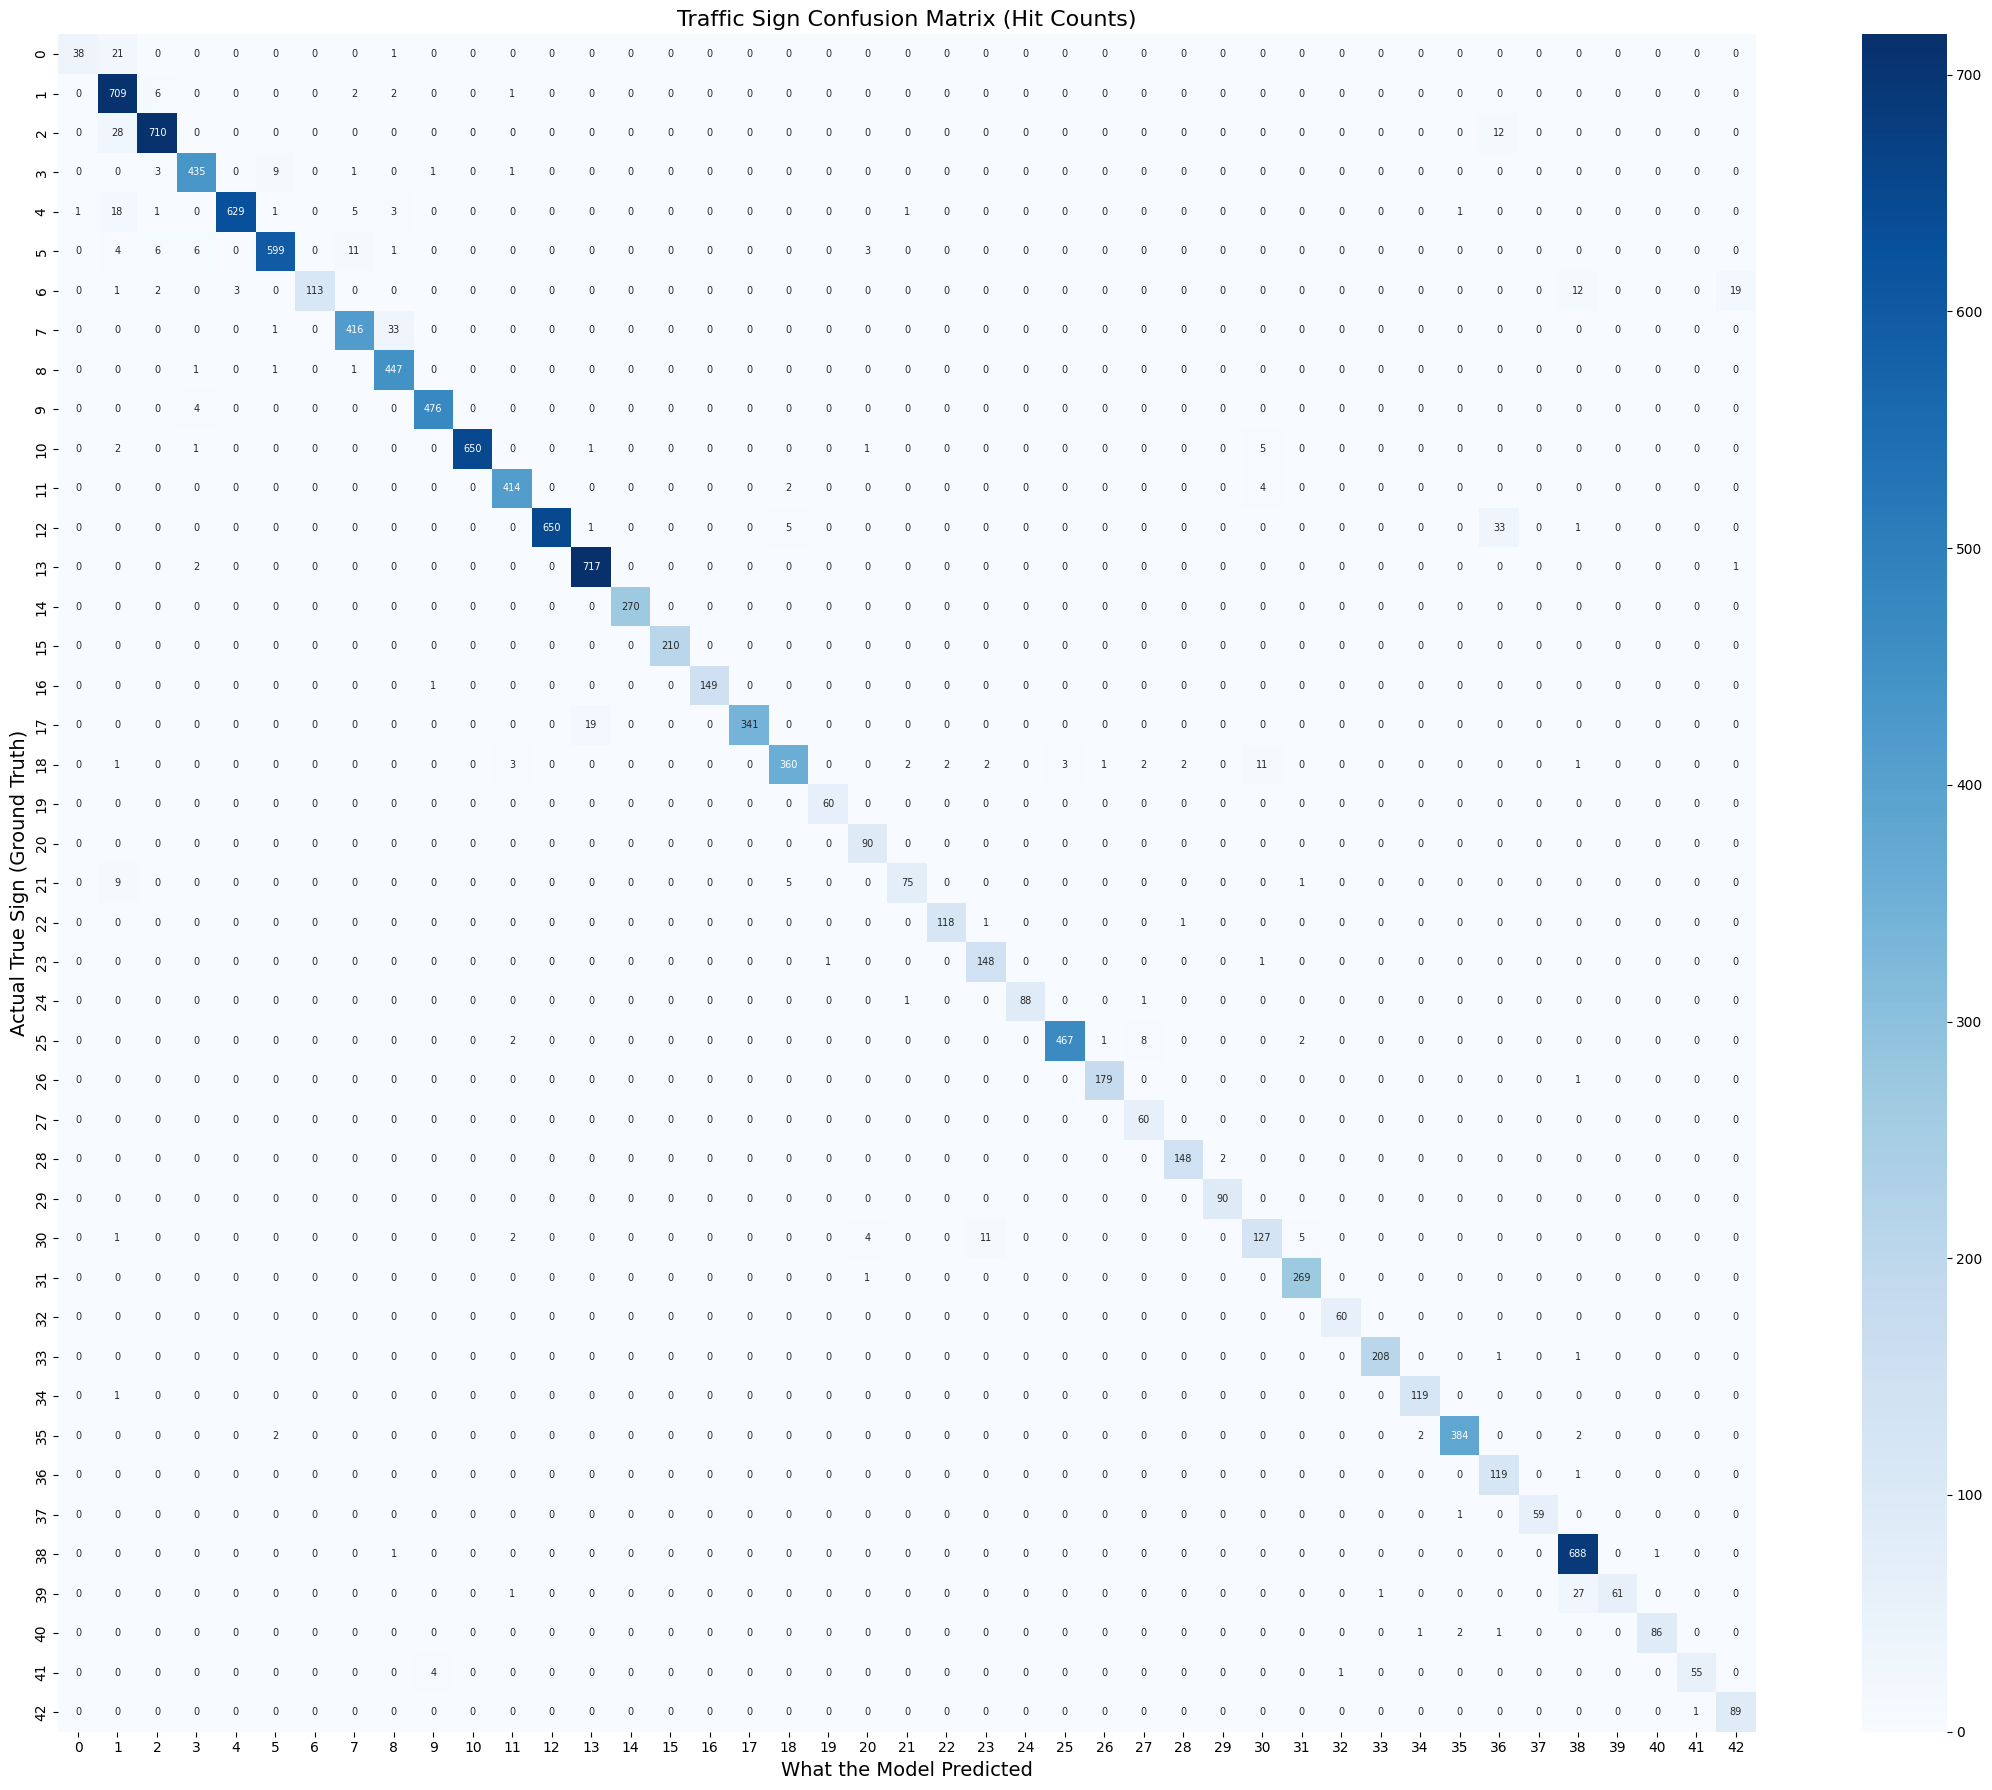

In [7]:
# ---------------------------------------------------------
# 7. Plotting the Heatmap with Hit Numbers
# ---------------------------------------------------------
plt.figure(figsize=(22, 18))

sns.heatmap(
    cm, 
    annot=True,             # Shows the number of hits inside each block
    annot_kws={"size": 7},  # Scales down text size so numbers fit perfectly
    cmap='Blues', 
    fmt='d'                 # Displays hits as normal integers (e.g. 145 instead of 1.45e2)
)

plt.title('Traffic Sign Confusion Matrix (Hit Counts)', fontsize=16)
plt.ylabel('Actual True Sign (Ground Truth)', fontsize=14)
plt.xlabel('What the Model Predicted', fontsize=14)
plt.tight_layout()

# Save a hard copy to your workspace automatically
plt.savefig('test_confusion_matrix.png', dpi=300)
print("Success! Matrix plotted and saved as 'test_confusion_matrix.png'")
plt.show()

In [8]:
from sklearn.metrics import classification_report

class_names = [classes[i] for i in range(NUM_CLASSES)]

report = classification_report(
    all_labels, 
    all_preds, 
    target_names=class_names, 
    digits=3
)

print("\n================ DETAILED CLASSIFICATION REPORT ================")
print(report)
print("================================================================")


================ DETAILED CLASSIFICATION REPORT ================
                               precision    recall  f1-score   support

         Speed limit (20km/h)      0.974     0.633     0.768        60
         Speed limit (30km/h)      0.892     0.985     0.936       720
         Speed limit (50km/h)      0.975     0.947     0.961       750
         Speed limit (60km/h)      0.969     0.967     0.968       450
         Speed limit (70km/h)      0.995     0.953     0.974       660
         Speed limit (80km/h)      0.977     0.951     0.964       630
  End of speed limit (80km/h)      1.000     0.753     0.859       150
        Speed limit (100km/h)      0.954     0.924     0.939       450
        Speed limit (120km/h)      0.916     0.993     0.953       450
                   No passing      0.988     0.992     0.990       480
 No passing veh over 3.5 tons      1.000     0.985     0.992       660
 Right-of-way at intersection      0.976     0.986     0.981       420
          